In [20]:
import requests

# API endpoint for deputies from legislature 57
url = "https://dadosabertos.camara.leg.br/api/v2/deputados"
params = {
    "idLegislatura": 57,
    "itens": 100,  # max per page
    "ordem": "ASC",
    "ordenarPor": "id"
}

all_deputies_57 = []
page = 1
while True:
    params["pagina"] = page
    try:
        response = requests.get(url, params=params)
        if response.status_code != 200:
            print(f"Request failed with status {response.status_code} on page {page}")
            break
        # Defensive: check if response is empty or not JSON
        if not response.text.strip():
            print(f"Empty response on page {page}")
            break
        try:
            data = response.json()
        except Exception as e:
            print(f"Failed to decode JSON on page {page}: {e}")
            break
        deputies = data.get("dados", [])
        if not deputies:
            break
        all_deputies_57.extend(deputies)
        if len(deputies) < params["itens"]:
            break
        page += 1
    except Exception as e:
        print(f"Error on page {page}: {e}")
        break

# Convert to DataFrame
df_deputies_57 = pd.DataFrame(all_deputies_57)

# Show how many unique deputies we got
num_unique_deputies_57 = df_deputies_57["id"].nunique()
print(f"Number of unique deputies from legislature 57: {num_unique_deputies_57}")



Number of unique deputies from legislature 57: 620


In [27]:
import time

# We'll collect the situation for each deputy in df_deputies_57
situations = []
for deputy_id in df_deputies_57["id"].unique():
    url = f"https://dadosabertos.camara.leg.br/api/v2/deputados/{deputy_id}"
    try:
        resp = requests.get(url)
        if resp.status_code == 200:
            data = resp.json()
            situacao = (
                data.get("dados", {})
                .get("ultimoStatus", {})
                .get("situacao", None)
            )
        else:
            print(f"Failed to fetch deputy {deputy_id}: status {resp.status_code}")
            situacao = None
    except Exception as e:
        print(f"Error fetching deputy {deputy_id}: {e}")
        situacao = None
    situations.append({"id": deputy_id, "situacao": situacao})
    time.sleep(0.1)  # be gentle to the API

# Merge the situation info into df_deputies_57
df_situations = pd.DataFrame(situations)
df_deputies_57 = df_deputies_57.merge(df_situations, on="id", how="left")

# Show a sample of the new column
print(df_deputies_57[["id", "nome", "situacao"]].head())


      id             nome   situacao
0  62881     Danilo Forte  Exercício
1  66385  Julio Arcoverde  Exercício
2  66828    Fausto Pinato  Exercício
3  68720   Fábio Henrique  Suplência
4  69871          Bacelar  Exercício


In [30]:
print("Valores únicos da coluna 'situacao':")
print(df_deputies_57["situacao"].unique())


Valores únicos da coluna 'situacao':
['Exercício' 'Suplência' 'Licença' 'Vacância' 'Suspenso']


In [32]:
# Quantos deputados únicos estão em "Exercicio"
num_exercicio = df_deputies_57[df_deputies_57["situacao"] == "Exercício"]["id"].nunique()
print(f"Número de deputados únicos em 'Exercicio': {num_exercicio}")

# Quantidade de deputados únicos para todos os tipos de situação
situacao_counts = df_deputies_57.groupby("situacao")["id"].nunique()
print("\nNúmero de deputados únicos por situação:")
print(situacao_counts)



Número de deputados únicos em 'Exercicio': 512

Número de deputados únicos por situação:
situacao
Exercício    512
Licença       31
Suplência     60
Suspenso       1
Vacância      16
Name: id, dtype: int64


In [35]:
df_deputies_57.head()

,id,uri,nome,siglaPartido,uriPartido,siglaUf,idLegislatura,urlFoto,email,situacao
0,62881,https://dadosabertos.camara.leg.br/api/v2/depu...,Danilo Forte,UNIÃO,https://dadosabertos.camara.leg.br/api/v2/part...,CE,57,https://www.camara.leg.br/internet/deputado/ba...,dep.daniloforte@camara.leg.br,Exercício
1,66385,https://dadosabertos.camara.leg.br/api/v2/depu...,Julio Arcoverde,PP,https://dadosabertos.camara.leg.br/api/v2/part...,PI,57,https://www.camara.leg.br/internet/deputado/ba...,dep.julioarcoverde@camara.leg.br,Exercício
2,66828,https://dadosabertos.camara.leg.br/api/v2/depu...,Fausto Pinato,PP,https://dadosabertos.camara.leg.br/api/v2/part...,SP,57,https://www.camara.leg.br/internet/deputado/ba...,dep.faustopinato@camara.leg.br,Exercício
3,68720,https://dadosabertos.camara.leg.br/api/v2/depu...,Fábio Henrique,UNIÃO,https://dadosabertos.camara.leg.br/api/v2/part...,SE,57,https://www.camara.leg.br/internet/deputado/ba...,None,Suplência
4,69871,https://dadosabertos.camara.leg.br/api/v2/depu...,Bacelar,PV,https://dadosabertos.camara.leg.br/api/v2/part...,BA,57,https://www.camara.leg.br/internet/deputado/ba...,dep.bacelar@camara.leg.br,Exercício


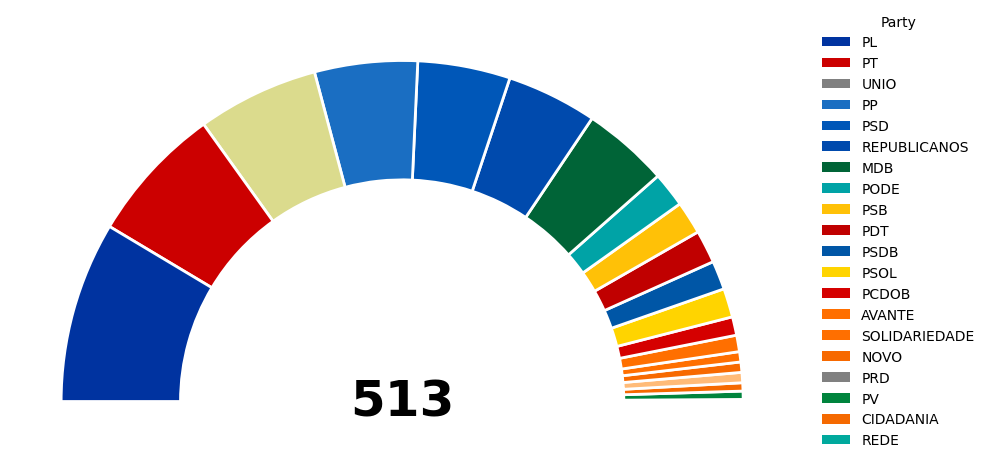

In [36]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Patch

# ----------------------------
# 1) Normalize party acronyms
# ----------------------------
def canon_party(s: str) -> str:
    s = (s or "").upper().strip()
    # strip accents/symbols -> keep only A-Z0-9
    s = re.sub(r'[^A-Z0-9]', '', s)

    # Common aliases / historical acronyms
    aliases = {
        'UNIAOBRASIL': 'UNIAO',
        'UNIAO': 'UNIAO',
        'UB': 'UNIAO',
        'PRB': 'REPUBLICANOS',
        'PPS': 'CIDADANIA',
        'SDD': 'SOLIDARIEDADE',
        'PATRI': 'PATRIOTA',
    }
    return aliases.get(s, s)

# --------------------------------------
# 2) Predominant party flag/brand color
#    (hex codes; add more as you need)
# --------------------------------------
party_color_hex = {
    'PT': '#CC0000',             # red
    'PL': '#0033A0',             # blue
    'MDB': '#006437',            # green
    'PP': '#1A6EC2',             # blue
    'PSD': '#0057B8',            # blue
    'REPUBLICANOS': '#004AAD',   # blue
    'UNIAO': '#0E3A8C',          # blue
    'PSDB': '#0056A6',           # blue
    'PDT': '#C00000',            # red
    'PSB': '#FFC107',            # yellow
    'PCDOB': '#D50000',          # red
    'PSOL': '#FFD400',           # yellow
    'REDE': '#00A99D',           # teal/green
    'PV': '#00843D',             # green
    'NOVO': '#F76900',           # orange
    'PODE': '#00A3A6',           # teal
    'CIDADANIA': '#F56900',      # orange
    'PSC': '#00843D',            # green
    'SOLIDARIEDADE': '#FF6F00',  # orange
    'AVANTE': '#FF6F00',         # orange
    'PATRIOTA': '#006838',       # green
    'PROS': '#0072CE',           # blue
    'PSL': '#FFD700',            # yellow
    'DEM': '#00A859',            # green (historical)
    'PTB': '#CC0000',            # red
    'PRTB': '#004AAD',           # blue
    'PR': '#B00020',             # red (historical)
    'PMN': '#D91C1C',            # red
    'PTC': '#0072CE',            # blue
    'AGIR': '#00AEEF',           # cyan
    # add any others you need here...
}

# --------------------------------------
# 3) Prepare data from df_deputies_57
#    (unique by id; count by party)
# --------------------------------------
# Use only deputies with situacao "Exercício" or "Suspenso"
filtered = (
    df_deputies_57[
        df_deputies_57["situacao"].isin(["Exercício", "Suspenso"])
    ][['id', 'siglaPartido']]
    .dropna(subset=['siglaPartido'])
    .drop_duplicates(subset=['id'], keep='last')
    .assign(party_norm=lambda d: d['siglaPartido'].map(canon_party))
)

total_unique = filtered['id'].nunique()
party_counts = filtered['party_norm'].value_counts()

# sort ASC so smallest start at the right, largest end at the left
party_counts = party_counts.sort_values(ascending=True)

parties = party_counts.index.tolist()
sizes = party_counts.values
fractions = sizes / sizes.sum()

# Build colors with fallbacks for unknown acronyms
fallback_cmap = plt.cm.get_cmap('tab20', len(parties))
colors = [
    party_color_hex.get(p, fallback_cmap(i))
    for i, p in enumerate(parties)
]

# --------------------------------------
# 4) Draw a true half-donut (top half)
# --------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_aspect('equal')
ax.axis('off')

outer_radius = 1.0
ring_width = 0.35
start_angle = 0.0      # draw from right (0°) toward left (180°)
total_angle = 180.0

theta = start_angle
for party, frac, color in zip(parties, fractions, colors):
    dtheta = frac * total_angle
    ax.add_patch(Wedge(
        center=(0, 0),
        r=outer_radius,
        theta1=theta,
        theta2=theta + dtheta,
        width=ring_width,
        facecolor=color,
        edgecolor='white',
        linewidth=2.0
    ))
    theta += dtheta

# center number only
ax.text(0, 0, f"{total_unique}", ha='center', va='center',
        fontsize=36, fontweight='bold')

# limit to the upper half nicely
margin = 0.15
ax.set_xlim(-outer_radius - margin, outer_radius + margin)
ax.set_ylim(-0.15, outer_radius + margin)

# Legend: largest → smallest, keep party colors consistent
legend_order = party_counts.sort_values(ascending=False).index.tolist()
handles = [Patch(facecolor=party_color_hex.get(p, 'gray'), edgecolor='none', label=p)
           for p in legend_order]
ax.legend(handles=handles, title="Party",
          loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.tight_layout()
plt.show()
